# OSNAP

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import iconspy as ispy
from iconspy.tests.conftest import get_ds_tgrid_lr

## Grid setup
Load the ICON grid file and produce an ICONSPy dataset

In [2]:
ds_tgrid = get_ds_tgrid_lr()  # This can be replaced with your own model tgrid
ds_IsD = ispy.convert_tgrid_data(ds_tgrid)
ds_IsD

<xarray.Dataset> Size: 7MB
Dimensions:                 (cell: 15105, vertex: 8067, edge: 23207, nc_e: 2,
                             nv_c: 3, ne_c: 3, nv_v: 6, ne_v: 6, nv_e: 2,
                             nc_v: 6, nc_c: 3, cart: 3)
Coordinates:
  * cell                    (cell) int32 60kB 0 1 2 3 ... 15102 15103 15104
    clon                    (cell) float64 121kB 69.12 73.0 ... 74.57 76.01
    clat                    (cell) float64 121kB 72.74 74.52 ... -46.83 -44.85
  * vertex                  (vertex) int32 32kB 0 1 2 3 ... 8063 8064 8065 8066
    vlon                    (vertex) float64 65kB 73.0 69.39 ... 80.59 77.56
    vlat                    (vertex) float64 65kB 73.27 71.49 ... -45.35 -45.49
  * edge                    (edge) int32 93kB 0 1 2 3 ... 23204 23205 23206
    elon                    (edge) float64 186kB 71.11 76.98 ... 75.34 76.04
    elat                    (edge) float64 186kB 72.39 73.25 ... -46.52 -45.54
Dimensions without coordinates: nc_e, nv_c, ne_c, nv_v, ne_v, nv_e, nc_v, nc_c,
                                cart
Data variables: (12/40)
    grid_sphere_radius      float64 8B 6.371e+06
    grav                    float64 8B 9.807
    earth_angular_velocity  float64 8B 7.292e-05
    rho0                    float64 8B 1.025e+03
    rhoi                    float64 8B 917.0
    rhos                    float64 8B 300.0
    ...                      ...
    edge_cart_vec           (edge, cart) float64 557kB 0.09797 ... -0.7137
    dual_edge_cart_vec      (edge, cart) float64 557kB 0.09801 ... -0.7136
    edge_prim_norm          (edge, cart) float64 557kB 0.6463 -0.7466 ... 0.7001
    fc                      (cell) float64 121kB 0.0001393 ... -0.0001029
    fe                      (edge) float64 186kB 0.000139 ... -0.0001041
    fv                      (vertex) float64 65kB 0.0001397 ... -0.000104
Attributes:
    converted_tgrid:      True
    boundary_BallTree:    <iconspy.balltree.IspyBoundaryBallTree object at 0x...
    wet_BallTree:         <iconspy.balltree.IspyWetBallTree object at 0x7ffb5...
    uuidOfHGrid:          5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    IsD_compatible_flag:  True

## Get the coordinates of the OSNAP-Array

In [3]:
# Open the mooring location files
import numpy as np
ds_osnap_west = xr.open_dataset(
    "https://swift.dkrz.de/v1/dkrz_7fa6baba-db43-4d12-a295-8e3ebb1a01ed/iconspy_test_data/OSNAP_mooring_positions_west.nc?temp_url_sig=0a2fb0675ab8e26fc5059903e5fb70b1a042c598&temp_url_expires=2036-07-11T11:41:31Z",
    engine="h5netcdf"
)

ds_osnap_east = xr.open_dataset(
    "https://swift.dkrz.de/v1/dkrz_7fa6baba-db43-4d12-a295-8e3ebb1a01ed/iconspy_test_data/OSNAP_mooring_positions_east.nc?temp_url_sig=e700534e9ce072aab794f0f6b6fd2a6b49f98f34&temp_url_expires=2036-07-11T11:42:22Z",
    engine="h5netcdf"
)

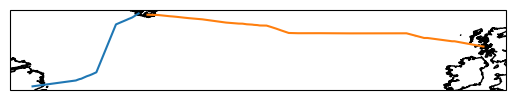

In [4]:
# Visualise the mooring positions
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

ax.plot(
    ds_osnap_west["lon_sect"],
    ds_osnap_west["lat_sect"],
    transform=ccrs.PlateCarree(),
)

ax.plot(
    ds_osnap_east["lon_sect"],
    ds_osnap_east["lat_sect"],
    transform=ccrs.PlateCarree(),
)

ax.coastlines()

## OSNAP-West
### Find stations
We begin by finding the stations which make up OSNAP-West and discarding any stations which duplicate vertices

Added OSNAP_West-West at vertex 900
Added C1/1872 at vertex 903
Skipped C1/1881 at vertex 903 because it is a duplicate
Skipped C2/1873 at vertex 903 because it is a duplicate
Skipped C2/1882 at vertex 903 because it is a duplicate
Skipped C3/1874 at vertex 903 because it is a duplicate
Skipped K7 at vertex 903 because it is a duplicate
Added K8 at vertex 890
Skipped DSOW1 at vertex 890 because it is a duplicate
Skipped K9 at vertex 890 because it is a duplicate
Skipped DSOW2 at vertex 890 because it is a duplicate
Added K10 at vertex 892
Skipped DSOW5 at vertex 892 because it is a duplicate
Added DSOW3 at vertex 906
Skipped LS8 at vertex 906 because it is a duplicate
Skipped DSOW4 at vertex 906 because it is a duplicate
Skipped LS7 at vertex 906 because it is a duplicate
Skipped LS6 at vertex 906 because it is a duplicate
Skipped LS5 at vertex 906 because it is a duplicate
Skipped LS4 at vertex 906 because it is a duplicate
Skipped LS3 at vertex 906 because it is a duplicate
Skipped L

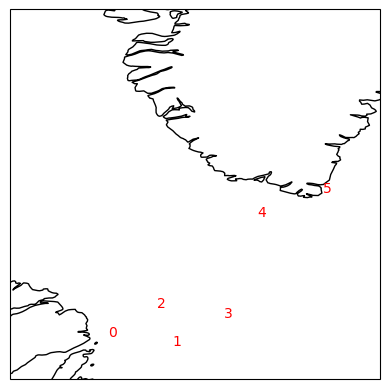

In [5]:
# Create a list of the target stations at OSNAP West
osnap_west_target_stations = []
for mooring in ds_osnap_west["mooring_name"].values:
    # Makr the boundary stations as such
    if mooring.startswith("OSNAP_West"):
        boundary = True
    else:
        boundary = None
    
    osnap_west_target_stations += [
        ispy.TargetStation(
            name=mooring,
            lon=float(ds_osnap_west["lon_sect"].sel(mooring_name=mooring).values),
            lat=float(ds_osnap_west["lat_sect"].sel(mooring_name=mooring).values),
            boundary=boundary,
        )
    ]
    
# Convert the target stations to model stations, but some of these may be duplicates.
_osnap_west_model_stations = [target_station.to_model_station(ds_IsD) for target_station in osnap_west_target_stations]
_osnap_west_model_stations

# Remove repeat stations
osnap_west_model_stations = []
osnap_west_model_stations_vertices = []
for model_station in _osnap_west_model_stations:
    if model_station.vertex not in osnap_west_model_stations_vertices:
        osnap_west_model_stations.append(model_station)
        osnap_west_model_stations_vertices.append(model_station.vertex)
        print(f"Added {model_station.name} at vertex {model_station.vertex}")
    else:
        print(f"Skipped {model_station.name} at vertex {model_station.vertex} because it is a duplicate")

# Visualise the model stations on a map
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

for i, model_station in enumerate(osnap_west_model_stations):
    ax.text(
        model_station.model_lon,
        model_station.model_lat,
        f"{i}",
        transform=ccrs.PlateCarree(),
        color="red",
    )
    
ax.coastlines()
ax.set_extent([-60, -40, 50, 70])

### Construct section

In [6]:
# First we generate a list of sections connecting the model stations
osnap_west_sections = []
for i in range(len(osnap_west_model_stations) - 1):
    model_station_a = osnap_west_model_stations[i]
    model_station_b = osnap_west_model_stations[i + 1]
        
    name = str(model_station_a.name) + " to " + str(model_station_b.name)
    print(name)
    osnap_west_sections.append(
        ispy.Section(
            name=name,
            model_station_a=model_station_a,
            model_station_b=model_station_b,
            ds_IsD=ds_IsD,
            section_type="great circle",
        )
    )
    
osnap_west_sections

OSNAP_West-West to C1/1872
C1/1872 to K8
K8 to K10
K10 to DSOW3
DSOW3 to OSNAP_West-East


[Section(OSNAP_West-West to C1/1872, OSNAP_West-West, C1/1872, great circle),
 Section(C1/1872 to K8, C1/1872, K8, great circle),
 Section(K8 to K10, K8, K10, great circle),
 Section(K10 to DSOW3, K10, DSOW3, great circle),
 Section(DSOW3 to OSNAP_West-East, DSOW3, OSNAP_West-East, great circle)]

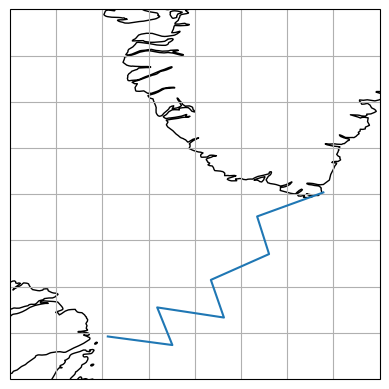

In [7]:
# Now we combine these sections and visualise
osnap_west_combined = ispy.CombinedSection("OSNAP West", osnap_west_sections, ds_IsD)
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
osnap_west_combined.plot(ax=ax)
ax.set_extent([-60, -40, 50, 70])

## OSNAP-East

Added OSNAP_East-West at vertex 908
Skipped CF1 at vertex 908 because it is a duplicate
Skipped CF2 at vertex 908 because it is a duplicate
Skipped CF3 at vertex 908 because it is a duplicate
Skipped CF4 at vertex 908 because it is a duplicate
Skipped CF5 at vertex 908 because it is a duplicate
Skipped CF6 at vertex 908 because it is a duplicate
Skipped CF7 at vertex 908 because it is a duplicate
Skipped NOC-M1 at vertex 908 because it is a duplicate
Added NOC-M2 at vertex 911
Skipped NOC-M3 at vertex 911 because it is a duplicate
Skipped FLMA at vertex 911 because it is a duplicate
Skipped FLMB at vertex 911 because it is a duplicate
Skipped NOC-M4 at vertex 911 because it is a duplicate
Skipped NOC-M5 at vertex 911 because it is a duplicate
Added IC0 at vertex 912
Skipped IC1 at vertex 912 because it is a duplicate
Added RREX Moor.1 IRW at vertex 1297
Skipped IC2 at vertex 1297 because it is a duplicate
Skipped RREX Moor.2 IRM at vertex 1297 because it is a duplicate
Skipped IC3 at v

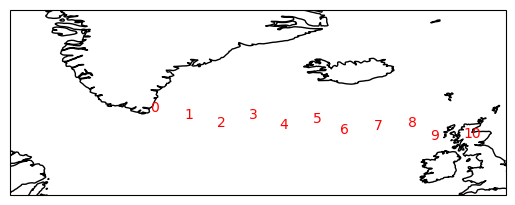

In [8]:
# Create a list of the target stations at OSNAP East
osnap_east_target_stations = []
for mooring in ds_osnap_east["mooring_name"].values:
    # Makr the boundary stations as such
    if mooring.startswith("OSNAP_East"):
        boundary = True
    else:
        boundary = None
    
    osnap_east_target_stations += [
        ispy.TargetStation(
            name=mooring,
            lon=float(ds_osnap_east["lon_sect"].sel(mooring_name=mooring).values),
            lat=float(ds_osnap_east["lat_sect"].sel(mooring_name=mooring).values),
            boundary=boundary,
        )
    ]
    
# Convert the target stations to model stations, but some of these may be duplicates.
_osnap_east_model_stations = [target_station.to_model_station(ds_IsD) for target_station in osnap_east_target_stations]
_osnap_east_model_stations

# Remove repeat stations
osnap_east_model_stations = []
osnap_east_model_stations_vertices = []
for model_station in _osnap_east_model_stations:
    # LS2 is one edge away from LS1 which causes things to break.
    # Need to fix ispy to cope with this
    if model_station.name.name == "LS2":
        print(f"Skipped {model_station.name} at vertex {model_station.vertex} because it is a near duplicate")
    elif model_station.vertex not in osnap_east_model_stations_vertices:
        osnap_east_model_stations.append(model_station)
        osnap_east_model_stations_vertices.append(model_station.vertex)
        print(f"Added {model_station.name} at vertex {model_station.vertex}")
    else:
        print(f"Skipped {model_station.name} at vertex {model_station.vertex} because it is a duplicate")

# Visualise the model stations on a map
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

for i, model_station in enumerate(osnap_east_model_stations):
    ax.text(
        model_station.model_lon,
        model_station.model_lat,
        f"{i}",
        transform=ccrs.PlateCarree(),
        color="red",
    )
    
ax.coastlines()
ax.set_extent([-60, 0, 50, 70])

In [9]:
osnap_east_sections = []
for i in range(len(osnap_east_model_stations) - 1):
    model_station_a = osnap_east_model_stations[i]
    model_station_b = osnap_east_model_stations[i + 1]
        
    name = str(model_station_a.name) + " to " + str(model_station_b.name)
    print(name)
    osnap_east_sections.append(
        ispy.Section(
            name=name,
            model_station_a=model_station_a,
            model_station_b=model_station_b,
            ds_IsD=ds_IsD,
            section_type="great circle",
        )
    )
    
osnap_east_sections

OSNAP_East-West to NOC-M2
NOC-M2 to IC0
IC0 to RREX Moor.1 IRW
RREX Moor.1 IRW to UM-D3
UM-D3 to UM-M3
UM-M3 to UM-M4
UM-M4 to SAMS Glider East Waypoint
SAMS Glider East Waypoint to RTWB1
RTWB1 to RTEB1
RTEB1 to OSNAP_East-East


[Section(OSNAP_East-West to NOC-M2, OSNAP_East-West, NOC-M2, great circle),
 Section(NOC-M2 to IC0, NOC-M2, IC0, great circle),
 Section(IC0 to RREX Moor.1 IRW, IC0, RREX Moor.1 IRW, great circle),
 Section(RREX Moor.1 IRW to UM-D3, RREX Moor.1 IRW, UM-D3, great circle),
 Section(UM-D3 to UM-M3, UM-D3, UM-M3, great circle),
 Section(UM-M3 to UM-M4, UM-M3, UM-M4, great circle),
 Section(UM-M4 to SAMS Glider East Waypoint, UM-M4, SAMS Glider East Waypoint, great circle),
 Section(SAMS Glider East Waypoint to RTWB1, SAMS Glider East Waypoint, RTWB1, great circle),
 Section(RTWB1 to RTEB1, RTWB1, RTEB1, great circle),
 Section(RTEB1 to OSNAP_East-East, RTEB1, OSNAP_East-East, great circle)]

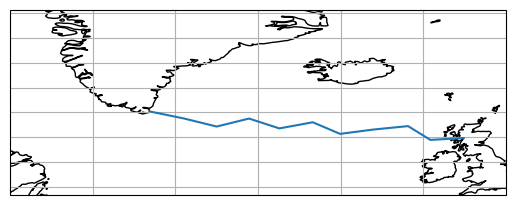

In [10]:
osnap_east_combined = ispy.CombinedSection("OSNAP East", osnap_east_sections, ds_IsD)
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
osnap_east_combined.plot(ax=ax)
ax.set_extent([-60, 0, 50, 70])

## Output in xarray formats

In [11]:
ds_osnap_east = osnap_east_combined.to_ispy_section()
ds_osnap_east

<xarray.Dataset> Size: 668B
Dimensions:           (step_in_path: 10, step_in_path_v: 11)
Coordinates:
  * step_in_path      (step_in_path) int64 80B 0 1 2 3 4 5 6 7 8 9
    elon              (step_in_path) float64 80B -40.95 -36.93 ... -10.47 -7.136
    elat              (step_in_path) float64 80B 59.69 58.78 ... 57.51 56.79
  * step_in_path_v    (step_in_path_v) int64 88B 0 1 2 3 4 5 6 7 8 9 10
    vlon              (step_in_path_v) float64 88B -43.04 -38.92 ... -5.111
    vlat              (step_in_path_v) float64 88B 60.1 59.25 ... 56.67 56.89
Data variables:
    edge_path         (step_in_path) int32 40B 2434 2433 3427 ... 3360 3386 3397
    vertex_path       (step_in_path_v) int32 44B 908 911 912 ... 1274 1284 1235
    path_orientation  (step_in_path) float64 80B 1.0 1.0 1.0 ... 1.0 1.0 -1.0
Attributes:
    date:          2026-07-14 14:12:18
    ispy version:  0.2.0
    uuidOfHGrid:   5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    section name:  OSNAP East
    Created by:    m301014

In [13]:
ds_osnap_west = osnap_east_combined.to_ispy_section()
ds_osnap_west

<xarray.Dataset> Size: 668B
Dimensions:           (step_in_path: 10, step_in_path_v: 11)
Coordinates:
  * step_in_path      (step_in_path) int64 80B 0 1 2 3 4 5 6 7 8 9
    elon              (step_in_path) float64 80B -40.95 -36.93 ... -10.47 -7.136
    elat              (step_in_path) float64 80B 59.69 58.78 ... 57.51 56.79
  * step_in_path_v    (step_in_path_v) int64 88B 0 1 2 3 4 5 6 7 8 9 10
    vlon              (step_in_path_v) float64 88B -43.04 -38.92 ... -5.111
    vlat              (step_in_path_v) float64 88B 60.1 59.25 ... 56.67 56.89
Data variables:
    edge_path         (step_in_path) int32 40B 2434 2433 3427 ... 3360 3386 3397
    vertex_path       (step_in_path_v) int32 44B 908 911 912 ... 1274 1284 1235
    path_orientation  (step_in_path) float64 80B 1.0 1.0 1.0 ... 1.0 1.0 -1.0
Attributes:
    date:          2026-07-14 14:12:56
    ispy version:  0.2.0
    uuidOfHGrid:   5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    section name:  OSNAP East
    Created by:    m301014